# Regresja logistyczna

## Import bibliotek

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

## Regresja liniowa próbuje być klasyfikatorem

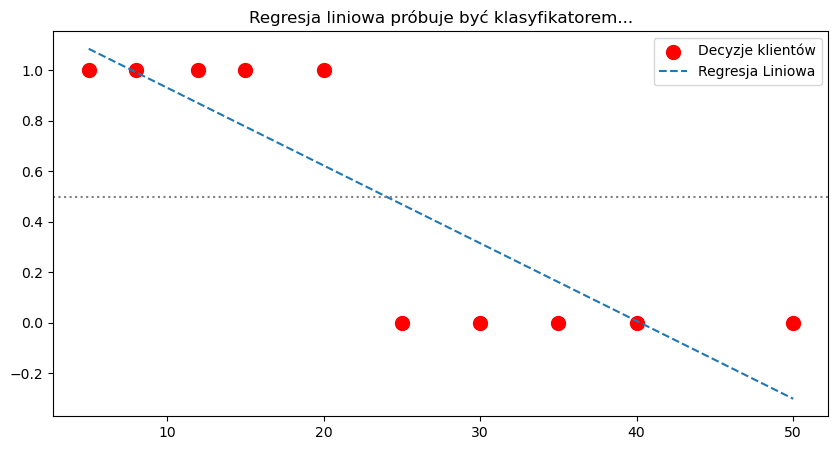

In [ ]:
# Dane: Cena Big Maca (zł) vs Czy kupiono (0/1)
cena = np.array([5, 8, 12, 15, 20, 25, 30, 35, 40, 50]).reshape(-1, 1)
decyzja = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

model_lin = LinearRegression().fit(cena, decyzja)

plt.figure(figsize=(10, 5))
plt.scatter(cena, decyzja, color='red', s=100, label='Decyzje klientów')
plt.plot(cena, model_lin.predict(cena), '--', label='Regresja Liniowa')
plt.axhline(0.5, color='gray', linestyle=':')
plt.title("Regresja liniowa próbuje być klasyfikatorem...")
plt.legend()
plt.show()

## Regresja Logistyczna na ratunek!

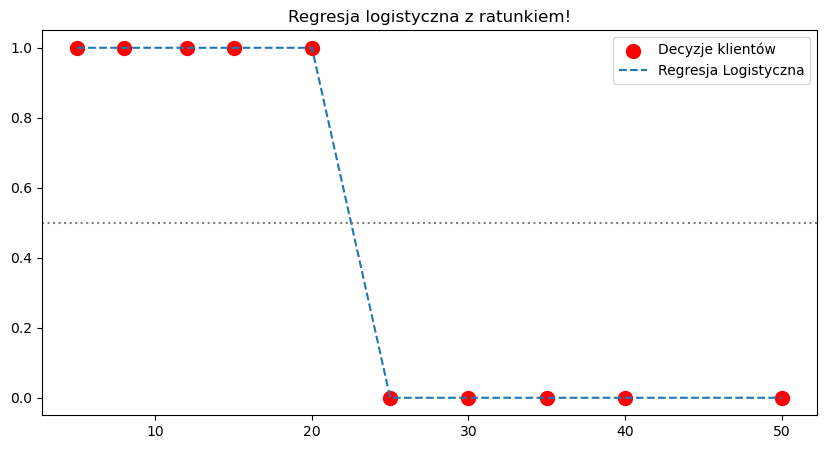

In [ ]:
model_log = LogisticRegression().fit(cena, decyzja)


plt.figure(figsize=(10, 5))
plt.scatter(cena, decyzja, color='red', s=100, label='Decyzje klientów')
plt.plot(cena, model_log.predict(cena), '--', label='Regresja Logistyczna')
plt.axhline(0.5, color='gray', linestyle=':')
plt.title("Regresja logistyczna na ratunek!")
plt.legend()
plt.show()

## Sigmoid - A po co to komu?

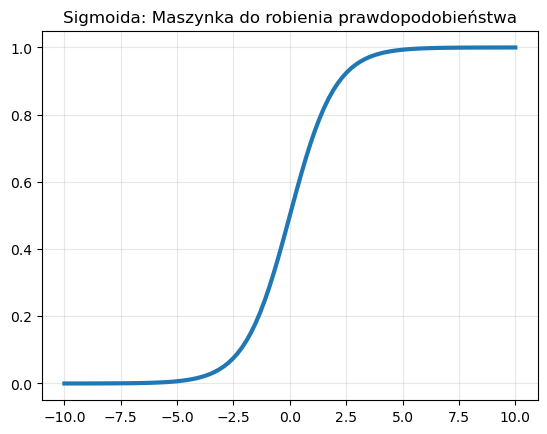

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 100)
plt.plot(z_values, sigmoid(z_values), lw=3)
plt.title("Sigmoida: Maszynka do robienia prawdopodobieństwa")
plt.grid(True, alpha=0.3)
plt.show()

## Jak oceniać nasz model?

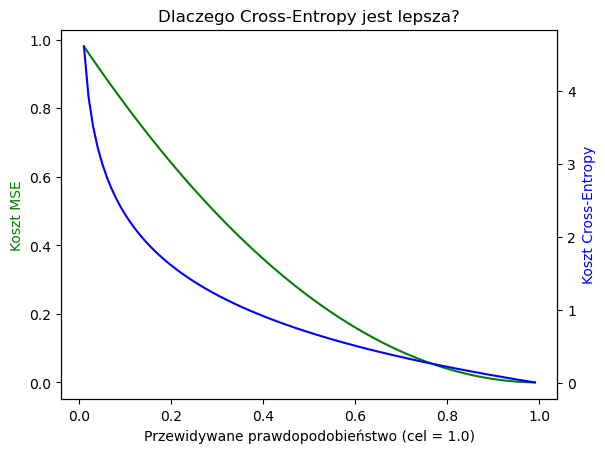

In [5]:
def mse_loss(y_true, y_pred):
    return (y_true - y_pred)**2

def cross_entropy_loss(y_true, y_pred):
    return - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Symulacja: Prawdziwa etykieta to 1 (Kupił).
# Sprawdzamy koszt dla różnych przewidywań modelu (od 0.01 do 0.99)
preds = np.linspace(0.01, 0.99, 100)
loss_mse = mse_loss(1, preds)
loss_ce = cross_entropy_loss(1, preds)

fig, ax1 = plt.subplots()

ax1.plot(preds, loss_mse, 'g-', label='MSE (Liniowa)')
ax2 = ax1.twinx()
ax2.plot(preds, loss_ce, 'b-', label='Cross-Entropy (Logistyczna)')

ax1.set_xlabel('Przewidywane prawdopodobieństwo (cel = 1.0)')
ax1.set_ylabel('Koszt MSE', color='g')
ax2.set_ylabel('Koszt Cross-Entropy', color='b')
plt.title("Dlaczego Cross-Entropy jest lepsza?")
plt.show()

# Decision Boundary czyli forma wizualizacji naszego algorytmu

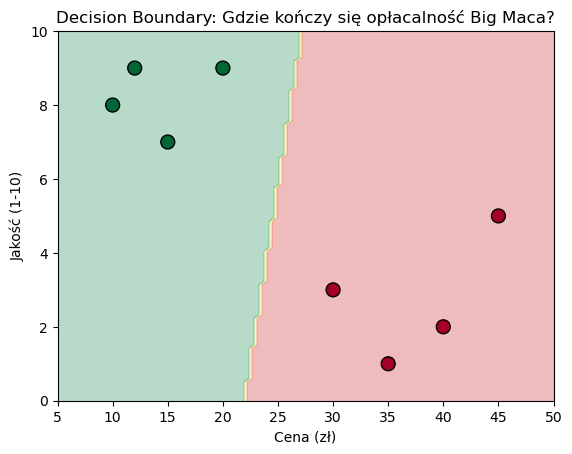

In [6]:
# Dane: [Cena, Jakość]
X = np.array([[10, 8], [15, 7], [20, 9], [30, 3], [40, 2], [45, 5], [12, 9], [35, 1]])
y = np.array([1, 1, 1, 0, 0, 0, 1, 0])

model = LogisticRegression().fit(X, y)

# Tworzenie siatki do rysowania tła
xx, yy = np.meshgrid(np.linspace(5, 50, 100), np.linspace(0, 10, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=100, cmap='RdYlGn')
plt.xlabel('Cena (zł)')
plt.ylabel('Jakość (1-10)')
plt.title("Decision Boundary: Gdzie kończy się opłacalność Big Maca?")
plt.show()

## Jak to sobie radzi z prawdziwymi danymi

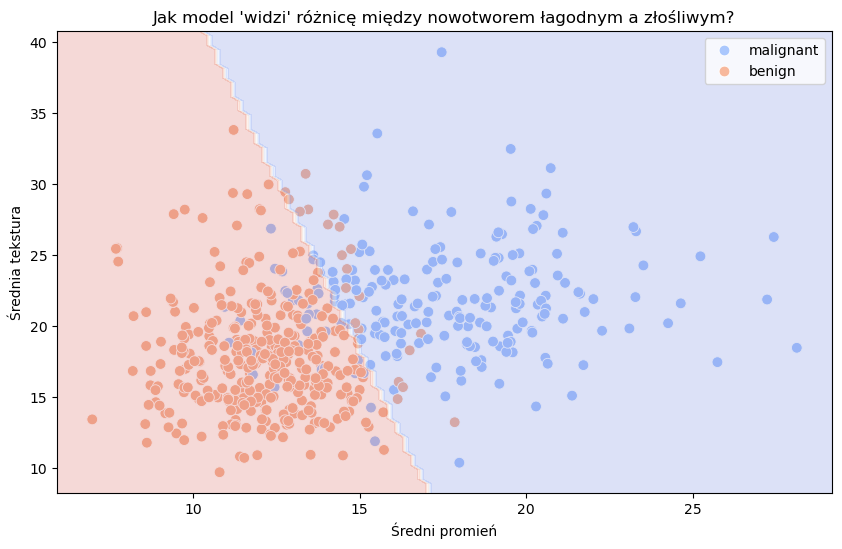

In [7]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import seaborn as sns

# 1. Ładowanie danych
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # 0: malignant (złośliwy), 1: benign (łagodny)

# 2. Wybieramy 2 cechy, żeby móc to narysować na 2D (dla zrozumienia idei)
# Wybieramy 'mean radius' i 'mean texture'
X = df[['mean radius', 'mean texture']].values
y = df['target'].values

# 3. Trening modelu
model = LogisticRegression()
model.fit(X, y)

# 4. Wizualizacja Granicy Decyzyjnej
plt.figure(figsize=(10, 6))

# Rysujemy punkty
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=data.target_names[y], palette='coolwarm', s=60)

# Tworzymy siatkę do tła
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Nakładamy kolorowe tło (granicę)
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.title("Jak model 'widzi' różnicę między nowotworem łagodnym a złośliwym?")
plt.xlabel("Średni promień")
plt.ylabel("Średnia tekstura")
plt.show()

## Spojler???

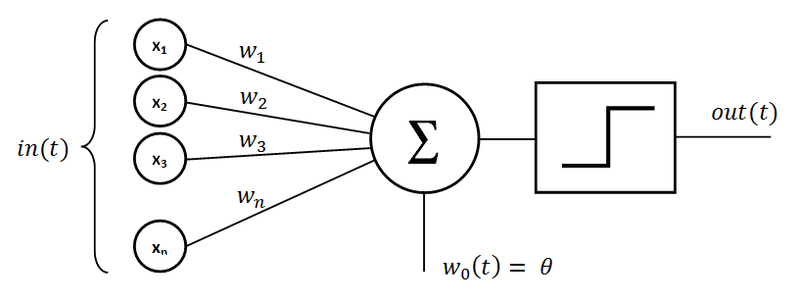